In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
robots = ['ROBOT_VACUUMING', 'ROBOT_MOPPING', 'ROBOT_DISHES', 'ROBOT_LAUNDRY', 'ROBOT_IRONING']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in robots or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
del row
del mid
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,ROBOT_DISHES,9996,14,,,,,10004,14,,,,,10000.0,0.0
1,2,0,ROBOT_VACUUMING,9996,14,,,,,10004,14,,,,,10000.0,0.0
2,2,0,ROBOT_MOPPING,9996,14,,,,,10004,14,,,,,10000.0,0.0
3,2,0,ROBOT_LAUNDRY,9996,14,,,,,10004,14,,,,,10000.0,0.0
4,2,0,ROBOT_IRONING,9996,14,,,,,10004,14,,,,,10000.0,0.0


In [2]:
#prices = prices[prices["product"].isin(robots)].copy()
chores = [s.split('_')[1] for s in robots]
bot = lambda s: prices[prices['product'] == f'ROBOT_{s}']

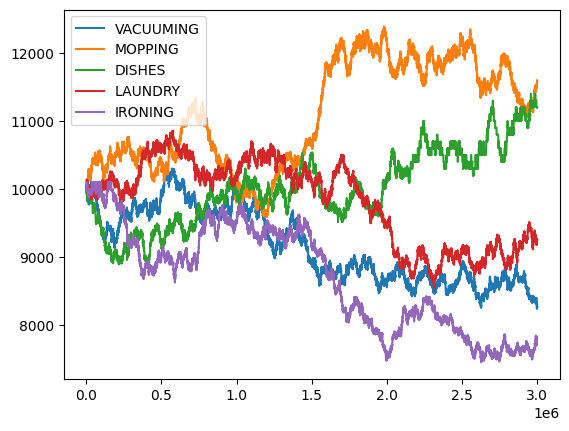

In [3]:
for p in chores:
    plt.plot(bot(p).timestamp, bot(p).mid_price, label=p)
plt.legend()
plt.show()

In [4]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()
#mids

<Axes: title={'center': 'Average mid across all ROBOTS'}, xlabel='timestamp'>

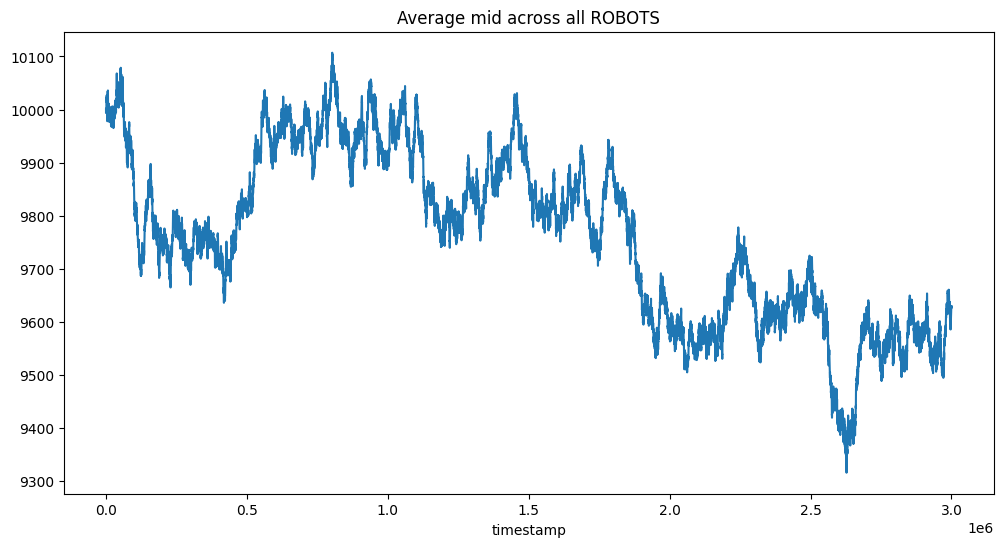

In [5]:
#pebble_cols = [c for c in mids.columns if c.startswith("ROBOT_")]
mids["ROBOT_avg"] = mids[robots].mean(axis=1)
mids["ROBOT_avg"].plot(figsize=(12, 6), title="Average mid across all ROBOTS")

MOPPING
count    29999.000000
mean         0.052918
std         11.145534
min        -43.000000
25%         -7.500000
50%          0.000000
75%          7.500000
max         46.500000
Name: mid_price, dtype: float64


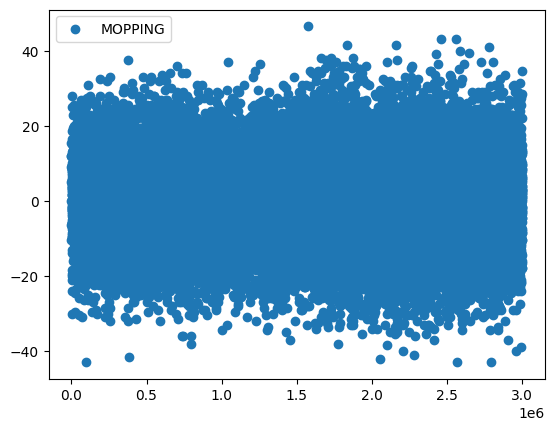

In [6]:
for p in chores[1:2]:
    y = bot(p).mid_price.diff()
    x = bot(p).timestamp
    plt.scatter(x, y, label=p)
    print(p)
    print(y.describe())
plt.legend()
plt.show()

In [15]:
assets = chores
for asset in assets[0:1]:
    tmp = bot(asset).mid_price
    log_returns = np.diff(np.log(tmp))
    diff = np.diff(tmp)
    
    # GBM in log space should be iid Gaussian
    print(f"Asset {asset}:")
    print(f"  ADF on levels: {adfuller(tmp)[1]:.4f}")  # should NOT reject
    print(f"  ADF on log-returns: {adfuller(log_returns)[1]:.4f}")  # should reject
    print(f"  Ljung-Box on log-returns:\n {acorr_ljungbox(log_returns, lags=5)}")  # should be white noise
    print(f"  Hurst: {compute_Hc(tmp)}")  # should be ~0.5
    print(f"  Skewness of log-returns: {stats.skew(log_returns):.4f}")
    print(f"  Excess kurtosis of log-returns: {stats.kurtosis(log_returns):.4f}")

Asset VACUUMING:
  ADF on levels: 0.5652
  ADF on log-returns: 0.0000
  Ljung-Box on log-returns:
     lb_stat  lb_pvalue
1  1.863221   0.172254
2  2.350002   0.308819
3  4.647415   0.199512
4  4.721869   0.317044
5  4.908858   0.427104
  Hurst: (np.float64(0.4959126763386021), np.float64(1.429842215894076), [[10, 17, 31, 56, 100, 177, 316, 562, 1000, 1778, 3162, 5623, 10000, 17782, 30000], [np.float64(3.9868321890314684), np.float64(5.425648968007118), np.float64(7.593728460897337), np.float64(10.632233514939552), np.float64(14.729781715912974), np.float64(19.891151466708486), np.float64(26.837007184218464), np.float64(35.333043473719464), np.float64(48.63994063438015), np.float64(63.93822503685278), np.float64(79.03906960443265), np.float64(96.48092884235534), np.float64(124.80028178230492), np.float64(178.83362639925812), np.float64(223.09726684760668)]])
  Skewness of log-returns: -0.0076
  Excess kurtosis of log-returns: 0.0192


## What kinds of driftless processes are these?
VACUUMING: Is a GBM  
MOPPING: Is autoregressive/momentum -- check ACF/PACF  
DISHES: Very weird. It is homoskedastic until the last 1/3 (basically day 4) where the log returns get pulled from either of two satellite distributions symmetrically around the main one (see plots below). Whatever strategy we use should either be robust to a sudden volatility spike or we should have one strategy for when the market is calm and another one for when it is volatile.  
LAUNDRY: Seems to be mean-reverting according to Hurst parameter -- check ACF/PACF  
IRONING: DEFINITELY autoregressive or some shi -- similar phenomenon to DISHES  
  
Further exploration: See if all of these assets exhibit regime shifts and/or if they all do it at the same time.

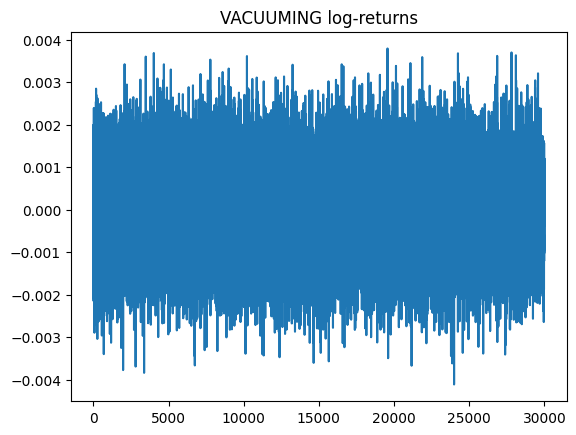

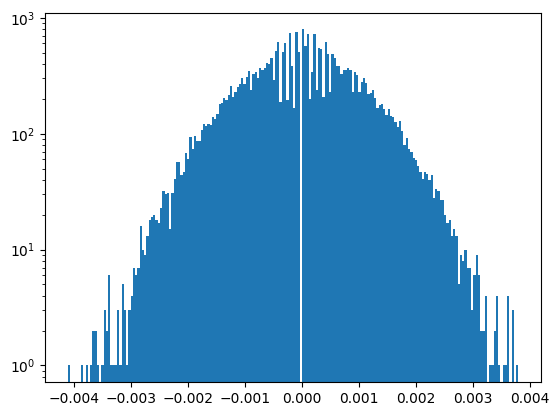

Text(0.5, 1.0, 'Q-Q Plot')

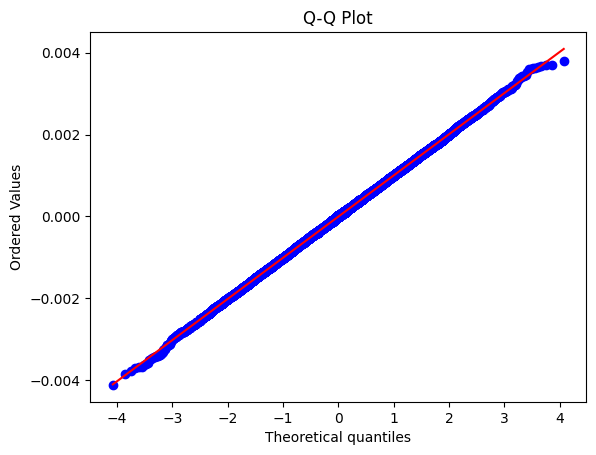

In [9]:
log_ret = np.diff(np.log(bot('VACUUMING').mid_price))
plt.plot(log_ret)
plt.title('VACUUMING log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

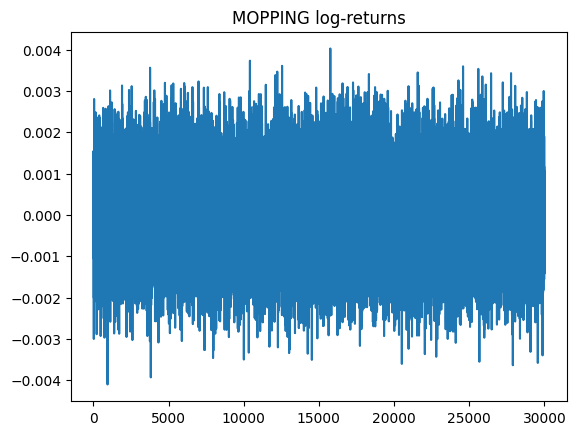

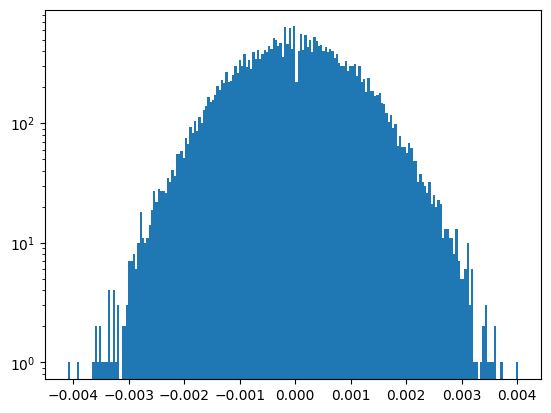

Text(0.5, 1.0, 'Q-Q Plot')

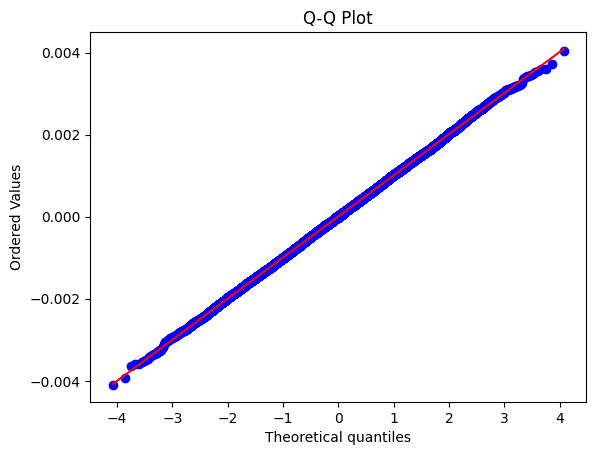

In [10]:
log_ret = np.diff(np.log(bot('MOPPING').mid_price))
plt.plot(log_ret)
plt.title('MOPPING log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

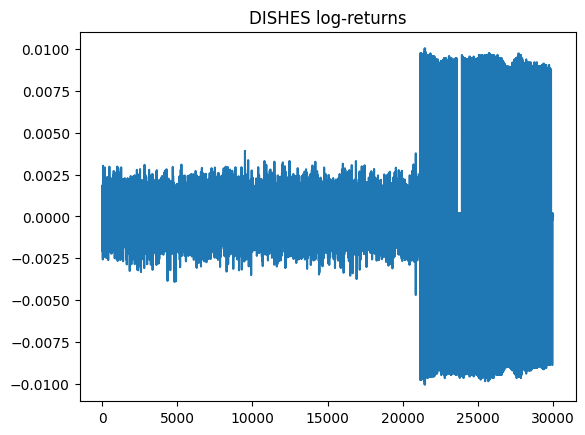

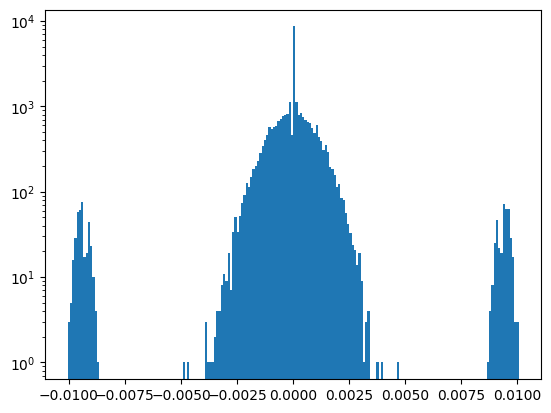

Text(0.5, 1.0, 'Q-Q Plot')

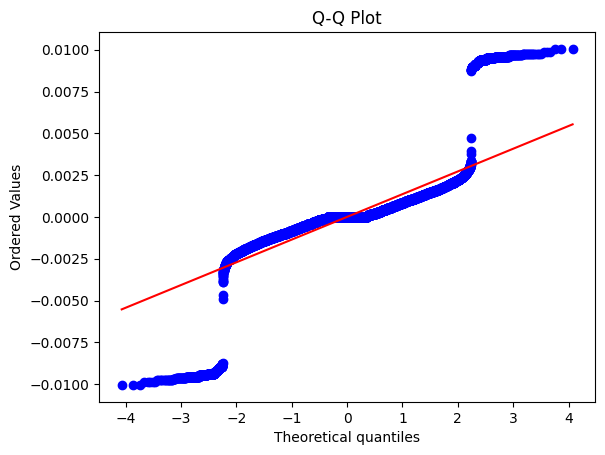

In [11]:
log_ret = np.diff(np.log(bot('DISHES').mid_price))
plt.plot(log_ret)
plt.title('DISHES log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

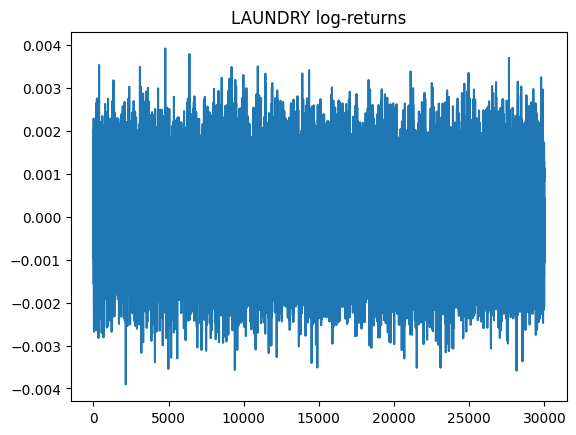

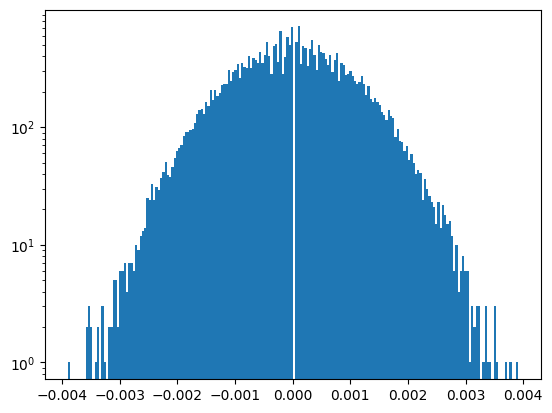

Text(0.5, 1.0, 'Q-Q Plot')

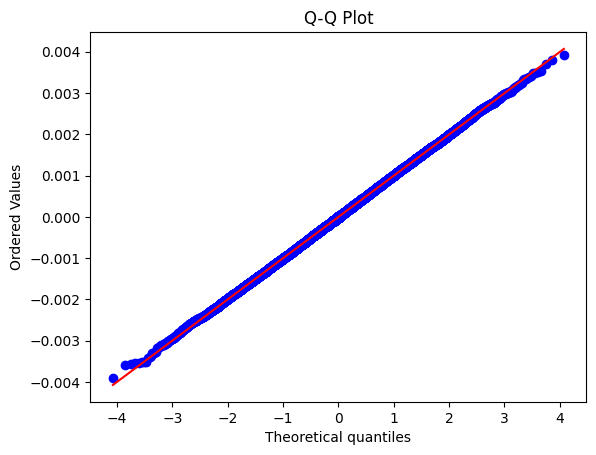

In [12]:
log_ret = np.diff(np.log(bot('LAUNDRY').mid_price))
plt.plot(log_ret)
plt.title('LAUNDRY log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

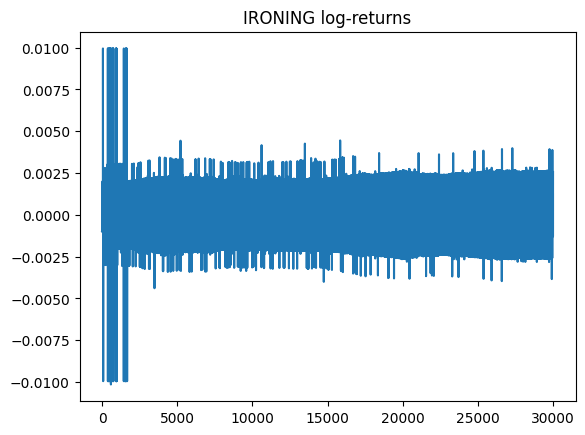

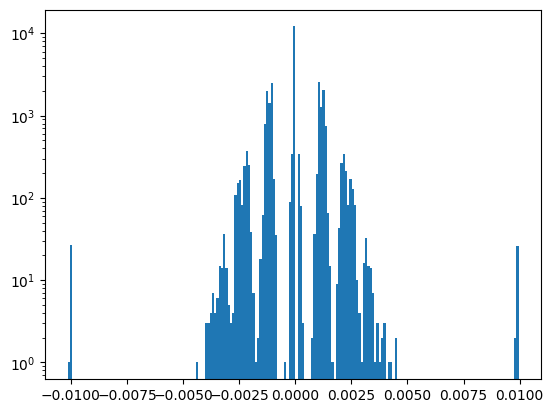

Text(0.5, 1.0, 'Q-Q Plot')

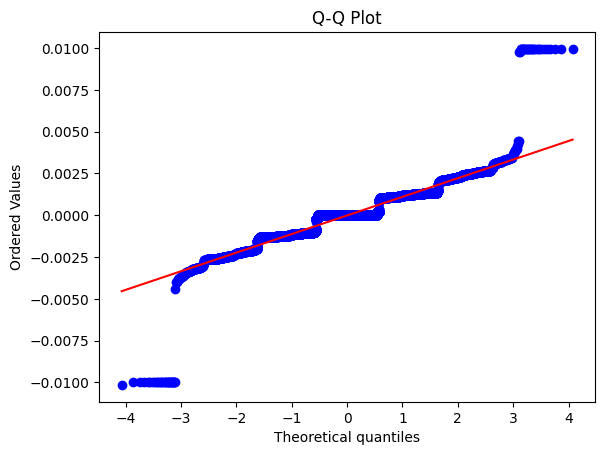

In [13]:
log_ret = np.diff(np.log(bot('IRONING').mid_price))
plt.plot(log_ret)
plt.title('IRONING log-returns')
plt.show()
# Also look at the distribution
plt.hist(log_ret, bins=200)
plt.yscale('log')  # log scale to see tail behavior
plt.show()
stats.probplot(log_ret, dist="norm", plot=plt)
plt.title('Q-Q Plot')

In [14]:
def estimate_gbm_params(prices, dt=1.0):
    """
    prices: price level series
    dt: time step size (1.0 if returns are already per-tick)
    """
    log_ret = np.diff(np.log(prices))
    n = len(log_ret)
    
    # MLE estimates
    mu_ret = np.mean(log_ret)       # mean log-return per tick
    sigma2 = np.var(log_ret, ddof=1) # variance of log-returns
    sigma = np.sqrt(sigma2 / dt)     # volatility per unit time
    
    # Drift of the price process (Ito correction)
    mu = mu_ret / dt + 0.5 * sigma2 / dt  # drift of S, not log(S)
    
    # Standard errors
    se_mu_ret = np.sqrt(sigma2 / n)
    se_sigma = sigma / np.sqrt(2 * (n-1))
    
    # t-stat for drift being nonzero
    t_stat = mu_ret / se_mu_ret
    
    return {
        'mu_log': mu_ret,        # mean log-return per tick
        'mu': mu,                # drift of price process
        'sigma': sigma,          # volatility
        'se_mu': se_mu_ret,      # std error of mean log-return
        'se_sigma': se_sigma,    # std error of sigma
        't_stat_drift': t_stat,  # is drift significantly nonzero?
    }

for asset in chores:
    params = estimate_gbm_params(bot(asset).mid_price)
    print(f"{asset}: mu_log={params['mu_log']:.6f} "
          f"(t={params['t_stat_drift']:.2f}) "
          f"sigma={params['sigma']:.6f}")

VACUUMING: mu_log=-0.000006 (t=-1.09) sigma=0.001006
MOPPING: mu_log=0.000005 (t=0.85) sigma=0.001002
DISHES: mu_log=0.000004 (t=0.38) sigma=0.001703
LAUNDRY: mu_log=-0.000003 (t=-0.45) sigma=0.000998
IRONING: mu_log=-0.000008 (t=-1.20) sigma=0.001177


# In Conclusion
IRONING and DISHES are subject to (seemingly random, unless someone can find a catalyst?) regime changes. The QQ-plots show that the log returns for the other assets are perfect normal distributions which confirms that they are GBMs. I actually want to test this for the microchips dataset as well.  
\\  
I ran the same code as above on the microchips and those are all GBMs.  
\\  
Claude now suggests running cointegration and/or PCA methods on these. I think Claude is right in saying that some linear combination of the assets in this and the microchip class will be arb-able